In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

1. Construção de um gráfico de barras para a classificação histórica do campeonato Brasileiro

In [13]:
query_classificacao = """
WITH pontos_partidas AS (
	SELECT
		mandante AS time,
        CASE
			WHEN gols_mandante > gols_visitante THEN 3
            WHEN gols_mandante = gols_visitante THEN 1
            ELSE 0
		END AS pontos,
        1 AS jogo,
        gols_mandante AS gols_feitos,
        gols_visitante AS gols_sofridos
	FROM partidas
        
	UNION ALL
    
    SELECT 
		visitante AS time,
        CASE
			WHEN gols_visitante > gols_mandante THEN 3
            WHEN gols_visitante = gols_mandante THEN 1
            ELSE 0
		END AS pontos,
        1 AS jogo,
        gols_visitante AS gols_feitos,
        gols_mandante AS gols_sofridos
	FROM partidas
)

SELECT 
	time,
    SUM(jogo) AS total_jogos,
    SUM(pontos) AS total_pontos,
    SUM(gols_feitos) AS gols_marcados,
    SUM(gols_sofridos) AS gols_sofridos,
    (SUM(gols_feitos) - SUM(gols_sofridos)) AS saldo_gols,
    ROUND(SUM(pontos) * 100.0 / (SUM(jogo) * 3), 2) AS aproveitamento_pct
FROM pontos_partidas
GROUP BY time
ORDER BY total_pontos DESC
LIMIT 20;
    """

In [15]:
import urllib.parse
from sqlalchemy import create_engine
import pandas as pd

usuario = 'root'
senha_original = 'V//03fff' 
senha_segura = urllib.parse.quote_plus(senha_original)

host = 'localhost'
porta = '3306'
nome_banco = 'brasileirao_db'

url_conexao = f'mysql+pymysql://{usuario}:{senha_segura}@{host}:{porta}/{nome_banco}'
engine = create_engine(url_conexao)
print("Engine criado com sucesso!")

Engine criado com sucesso!


In [16]:
df_plot = pd.read_sql(query_classificacao, con=engine)

C:\Users\Cristiane\AppData\Local\Temp\ipykernel_17532\820991611.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='total_pontos', y='time', palette='rocket')


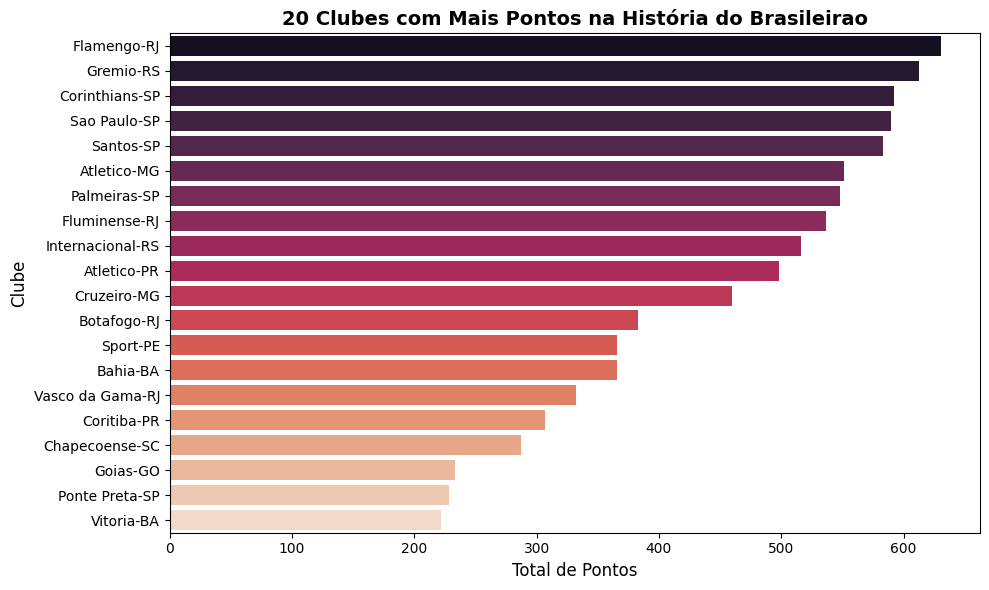

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x='total_pontos', y='time', palette='rocket')

plt.title('20 Clubes com Mais Pontos na História do Brasileirao', fontsize=14, fontweight='bold')
plt.xlabel('Total de Pontos', fontsize=12)
plt.ylabel('Clube', fontsize=12)
plt.tight_layout()

plt.show()

2. Construção de um gráfico de setores para o fator casa

In [21]:
query_casa = """ 
SELECT
	COUNT(*) AS total_jogos,
    
    # Analisando a porcentagem de vitória dos mandantes
    SUM(CASE WHEN gols_mandante > gols_visitante THEN 1 ELSE 0 END) AS vitorias_mandante,
    ROUND(SUM(CASE WHEN gols_mandante > gols_visitante THEN 1 ELSE 0 END) * 100.0 / COUNT(*),2) as porcentagem_vitoria_mandante,
    
    # Analisando a porcentagem de vitórias dos visitantes
    SUM(CASE WHEN gols_visitante > gols_mandante THEN 1 ELSE 0 END) AS vitorias_visitantes,
    ROUND(SUM(CASE WHEN gols_visitante > gols_mandante THEN 1 ELSE 0 END) * 100.0 / COUNT(*),2) AS porcentagem_vitoria_visitante,
    
    # Analisando a porcentagem de empates
    SUM(CASE WHEN gols_visitante = gols_mandante THEN 1 ELSE 0 END) AS empates,
    ROUND(SUM(CASE WHEN gols_visitante = gols_mandante THEN 1 ELSE 0 END) * 100.0 / COUNT(*),2) AS porcentagem_empates

FROM partidas;"""

In [28]:
df_casa = pd.read_sql(query_casa, con=engine)

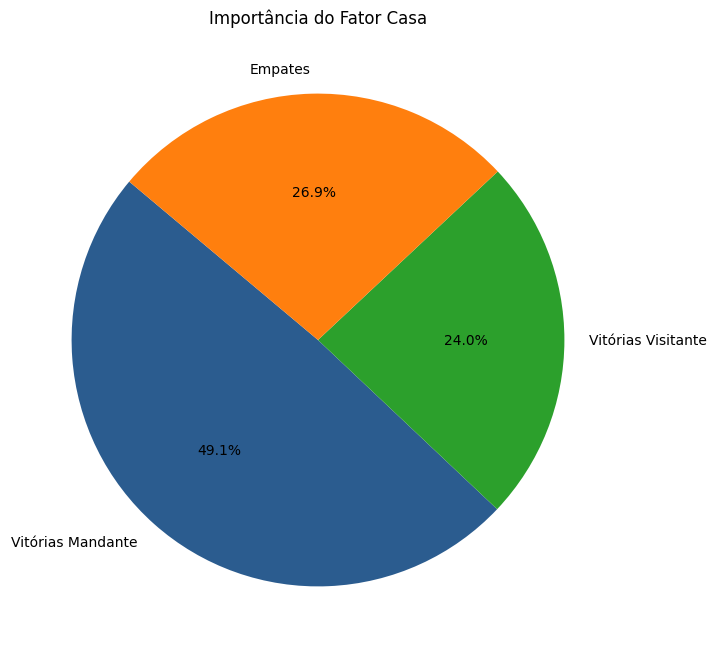

In [34]:
labels = ['Vitórias Mandante', 'Vitórias Visitante', 'Empates']
valores = [
    df_casa['vitorias_mandante'].iloc[0], 
    df_casa['vitorias_visitantes'].iloc[0], 
    df_casa['empates'].iloc[0]
]

plt.figure(figsize=(8, 8))
cores = ['#2b5c8f', '#2ca02c', '#ff7f0e']

plt.pie(
    valores, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=cores         
)
plt.title("Importância do Fator Casa")
plt.show()